# Phase 1 — Kalman Filter Baseline

AR(10) state-space model with Kalman predict/update, evaluated on
a 60-second segment at SNR ∈ {−5, 0, 5, 10, 15} dB.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
from audio_io import (
    load_mono_16k, loop_to_length, mix_at_snr,
    peak_normalize, save_wav, TARGET_SR
)
from kalman import (
    fit_ar_per_frame, kalman_filter_signal, estimate_R,
    compute_snr
)

AUDIO_DIR = pathlib.Path.cwd().parent / 'Audios'
OUT_DIR   = pathlib.Path.cwd().parent / 'data' / 'synth'
SNRS      = [-5, 0, 5, 10, 15]

doctor  = load_mono_16k(AUDIO_DIR / 'Doctor.wav')
patient = load_mono_16k(AUDIO_DIR / 'Patient.wav')
noise_raw = load_mono_16k(AUDIO_DIR / 'Background_Noise.wav')
min_len = min(len(doctor), len(patient))
clean_full = peak_normalize(0.5*(doctor[:min_len]+patient[:min_len]))
noise_full = loop_to_length(noise_raw, min_len)

seg_start = 30 * TARGET_SR
seg_dur   = 60 * TARGET_SR
clean = clean_full[seg_start:seg_start+seg_dur]
noise = noise_full[seg_start:seg_start+seg_dur]
ar_frames = fit_ar_per_frame(clean, order=10) # Fit AR(10) coefficients per frame

/Users/miguel/Documents/PoD/Information-Theory-Inference/Project_Miguel/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Run Kalman at all SNRs

In [3]:
results = {}
for snr_db in SNRS:
    noisy = mix_at_snr(clean, noise, snr_db) 
    R = estimate_R(clean, noisy)
    x_hat = kalman_filter_signal(noisy, ar_frames, R, order=10)
    snr_in  = compute_snr(clean, noisy)
    snr_out = compute_snr(clean, x_hat)
    results[snr_db] = {'noisy': noisy, 'x_hat': x_hat,
                       'snr_in': snr_in, 'snr_out': snr_out}
    print(f'SNR={snr_db:+3d}dB | In={snr_in:+.2f} | Out={snr_out:+.2f} | Gain={snr_out-snr_in:+.2f} dB')

SNR= -5dB | In=-5.00 | Out=-0.65 | Gain=+4.35 dB


SNR= +0dB | In=+0.00 | Out=+3.41 | Gain=+3.41 dB


SNR= +5dB | In=+5.00 | Out=+7.68 | Gain=+2.68 dB


SNR=+10dB | In=+10.00 | Out=+12.13 | Gain=+2.13 dB


SNR=+15dB | In=+15.00 | Out=+16.72 | Gain=+1.72 dB


## 2. Output-SNR vs Input-SNR curve

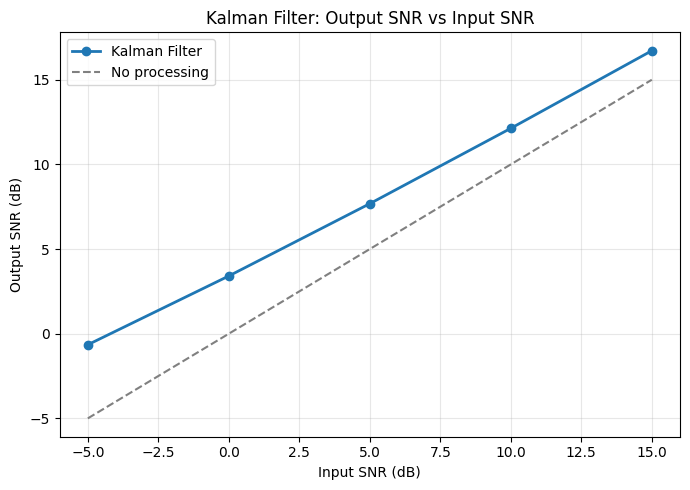

In [4]:
ins  = [results[s]['snr_in']  for s in SNRS]
outs = [results[s]['snr_out'] for s in SNRS]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ins, outs, 'o-', label='Kalman Filter', linewidth=2)
ax.plot(ins, ins, '--', color='gray', label='No processing')
ax.set_xlabel('Input SNR (dB)')
ax.set_ylabel('Output SNR (dB)')
ax.set_title('Kalman Filter: Output SNR vs Input SNR')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'kalman_snr_curve.png'), dpi=150)
plt.show()

## 3. Spectrograms: clean vs noisy vs filtered (0 dB)

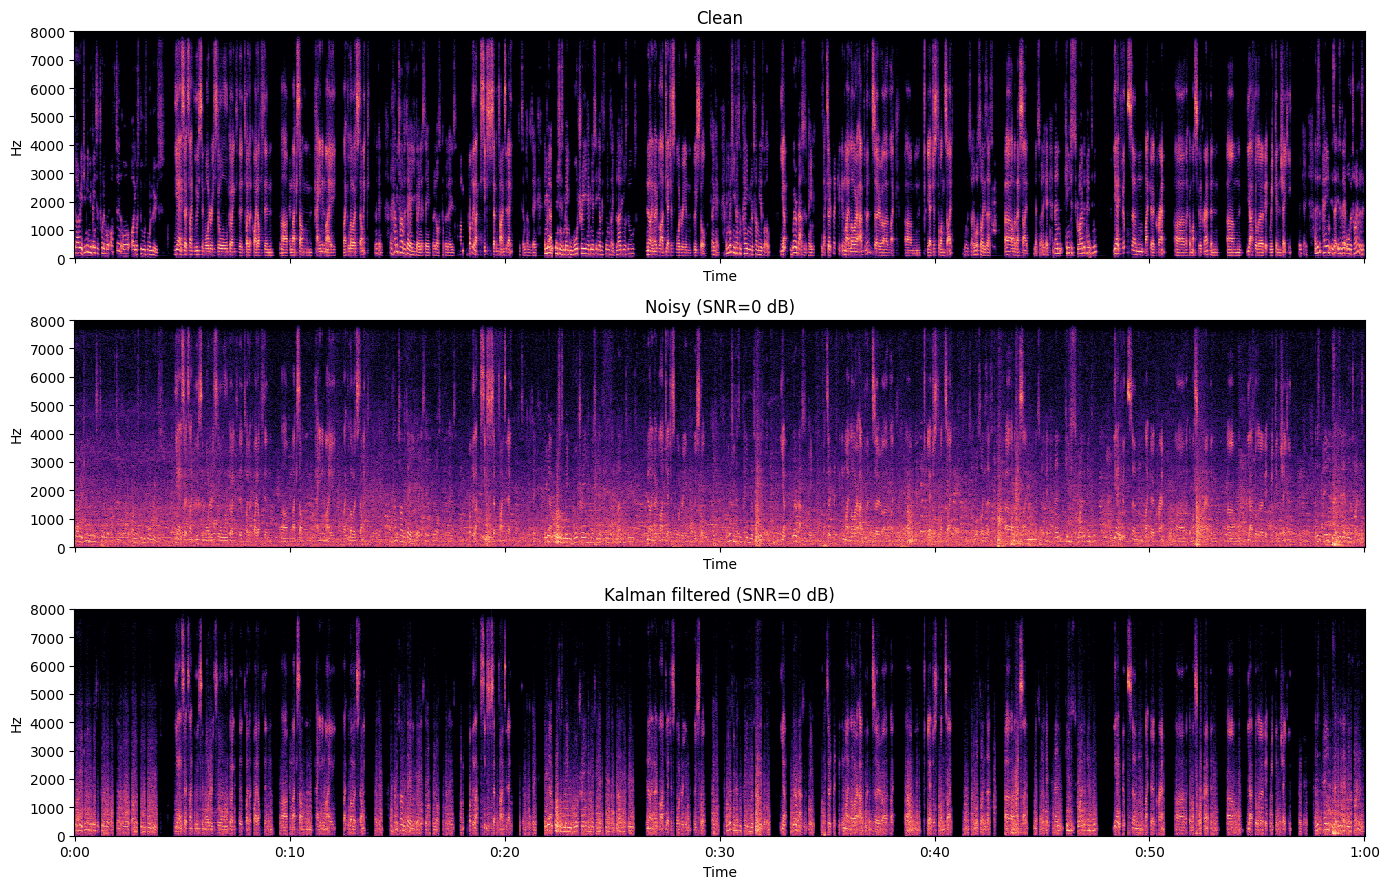

In [5]:
snr_show = 0
noisy_show = results[snr_show]['noisy']
xhat_show  = results[snr_show]['x_hat']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, sig, title in zip(axes,
    [clean, noisy_show, xhat_show],
    ['Clean', f'Noisy (SNR={snr_show} dB)', f'Kalman filtered (SNR={snr_show} dB)']):
    S = librosa.amplitude_to_db(np.abs(librosa.stft(sig)), ref=np.max)
    librosa.display.specshow(S, sr=TARGET_SR, x_axis='time', y_axis='hz', ax=ax)
    ax.set_title(title)
    ax.set_ylim(0, 8000)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'kalman_spectrograms.png'), dpi=150)
plt.show()

## 4. Waveform zoom-in (2 seconds)

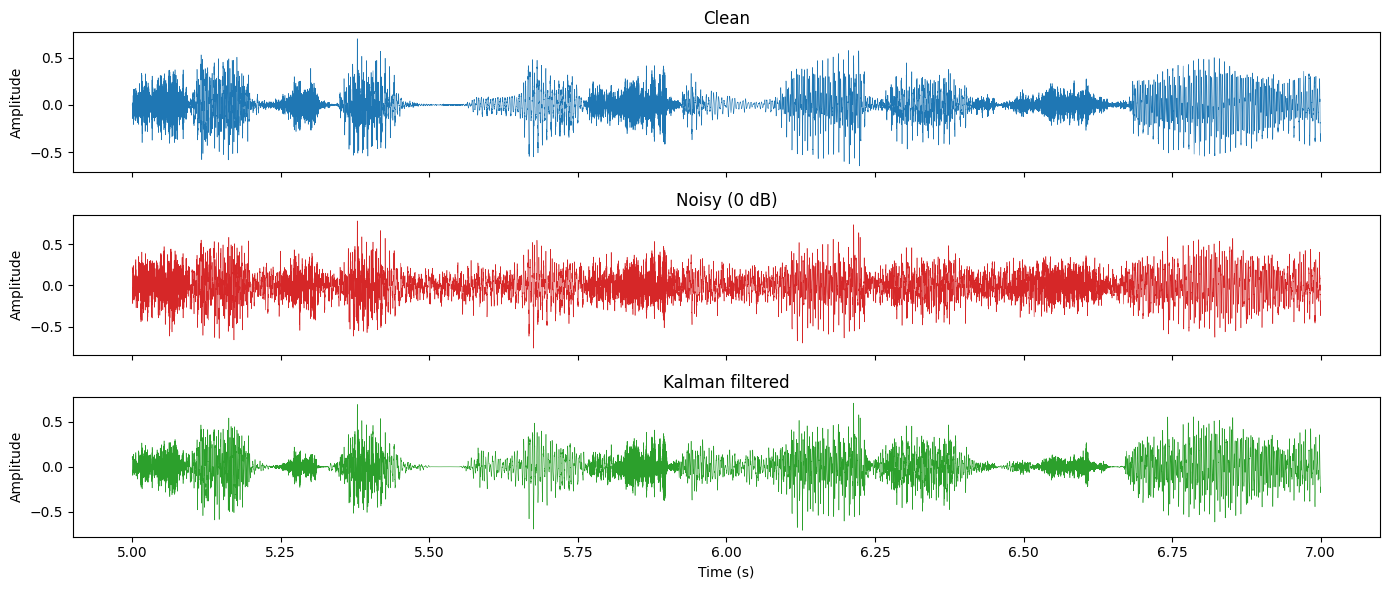

In [6]:
t0, dur = 5 * TARGET_SR, 2 * TARGET_SR
t = np.arange(dur) / TARGET_SR + 5

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
for ax, sig, title, color in zip(axes,
    [clean[t0:t0+dur], noisy_show[t0:t0+dur], xhat_show[t0:t0+dur]],
    ['Clean', 'Noisy (0 dB)', 'Kalman filtered'],
    ['tab:blue', 'tab:red', 'tab:green']):
    ax.plot(t, sig, linewidth=0.4, color=color)
    ax.set_title(title)
    ax.set_ylabel('Amplitude')
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'kalman_waveforms.png'), dpi=150)
plt.show()